# Water-Aware Crop Recommendation — Multi-Source Explainable Stacking Framework
Integrating soil, climate, and water data

## 1 · Imports & Configuration

In [1]:
# Suppress only known, harmless deprecation warnings from third-party libraries.
# We never suppress ALL warnings — actionable warnings must remain visible.
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_validate, train_test_split
)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

# ── Global constants ───────────────────────────────────────────────────────────
SEED   = 42
N_JOBS = -1
# Use a Generator (modern NumPy) instead of the legacy global seed.
rng = np.random.default_rng(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All imports OK.')

All imports OK.


## 2 · Data Loading

In [2]:
# The first 11 rows are NASA metadata headers — we skip them.
nasa_raw = pd.read_csv(
    'POWER_Point_Daily_20150101_20250101_010d50N_007d50E_LST.csv', skiprows = 11)
nasa_raw.head()

,YEAR,DOY,T2M,RH2M,PRECTOTCORR
0,2015,1,20.94,31.31,0.0
1,2015,2,20.16,30.25,0.0
2,2015,3,19.31,29.13,0.0
3,2015,4,18.20,28.36,0.0
4,2015,5,17.80,29.69,0.0


In [3]:
nasa_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         3654 non-null   int64  
 1   DOY          3654 non-null   int64  
 2   T2M          3654 non-null   float64
 3   RH2M         3654 non-null   float64
 4   PRECTOTCORR  3654 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 142.9 KB


In [4]:
nasa_raw = nasa_raw.drop(columns=['DOY'], errors='ignore')

In [5]:
print(f'Duplicates: {nasa_raw.duplicated().sum()}')

Duplicates: 0


In [6]:
print('No missing values:', nasa_raw.isnull().sum().sum() == 0)

No missing values: True


In [7]:
# Summarise NASA climate into scalar statistics used later in feature engineering.
nasa_stats = {
    'temp_median' : nasa_raw['T2M'].median(),
    'temp_std'    : nasa_raw['T2M'].std(),
    'rh_median'   : nasa_raw['RH2M'].median(),
    'rh_std'      : nasa_raw['RH2M'].std(),
    'precip_mean' : nasa_raw['PRECTOTCORR'].mean(),
    'precip_std'  : nasa_raw['PRECTOTCORR'].std(),
}
pd.Series(nasa_stats).rename('Value').to_frame().round(4)

,Value
temp_median,24.0100
temp_std,2.7390
rh_median,72.3150
rh_std,21.6940
precip_mean,7.3834
precip_std,24.9123


In [8]:
# World Bank / FAO water indicator scalars (national-level aggregates for Nigeria).
# NOTE: These are country-level medians applied uniformly — acknowledged limitation.
water_stats = {
    'stress_median'  : pd.read_csv('WB_WDI_ER_H2O_FWST_ZS.csv')['OBS_VALUE'].median(),
    'withdraw_median': pd.read_csv('FAO_AS_4254 (1).csv')['OBS_VALUE'].median(),
    'irrig_median'   : pd.read_csv('WB_WDI_AG_LND_IRIG_AG_ZS.csv')['OBS_VALUE'].median(),
}
pd.Series(water_stats).rename('Value').to_frame().round(4)

,Value
stress_median,12.0890
withdraw_median,62.4359
irrig_median,5.8261


In [9]:
# Crop recommendation base dataset.
df = pd.read_csv('Crop_recommendation.csv')

print(f'Shape   : {df.shape}')
print(f'Crops   : {df["label"].nunique()} unique classes')
print(f'Min rows/class: {df["label"].value_counts().min()}')

Shape   : (2200, 8)
Crops   : 22 unique classes
Min rows/class: 100


In [10]:
df.head(3)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice


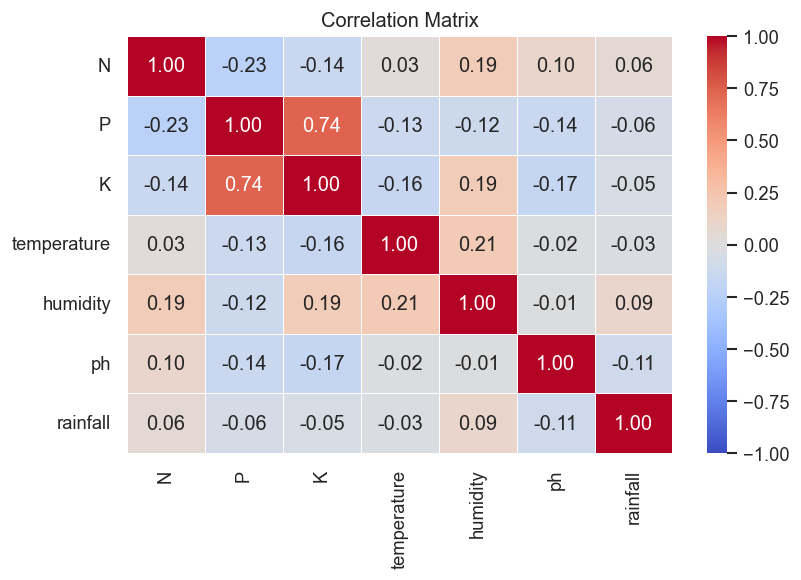

In [11]:
# Exploratory: raw feature correlation heatmap.
raw_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df[raw_features].corr(), annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.4, vmin=-1, vmax=1, ax=ax
)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('corr_matrix.png', dpi=150)
plt.show()

In [12]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [13]:
df["label"].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

## 3 · Feature Engineering

In [14]:
def engineer_features(
    df: pd.DataFrame,
    nasa_stats: dict,
    water_stats: dict
) -> pd.DataFrame:
    """
    Add all novel engineered features to the crop dataframe.

    Novelty: crop-climate compatibility scores measure how closely each
    crop's agronomic requirements match Kaduna's observed NASA POWER climate.
    Water stress indices incorporate World Bank / FAO national water data.

    Parameters
    ----------
    df          : Raw crop recommendation dataframe.
    nasa_stats  : Scalar summary statistics from NASA POWER climate data.
    water_stats : Scalar water indicators from World Bank / FAO.

    Returns
    -------
    DataFrame with original columns plus 11 engineered features.
    """
    out = df.copy()

    # ── Crop-climate compatibility scores ─────────────────────────────────────
    # Negative z-score of deviation: higher = closer match to Kaduna climate.
    out['temp_compat_score'] = -(
        np.abs(out['temperature'] - nasa_stats['temp_median'])
        / (nasa_stats['temp_std'] + 1e-9)
    )
    out['humidity_compat_score'] = -(
        np.abs(out['humidity'] - nasa_stats['rh_median'])
        / (nasa_stats['rh_std'] + 1e-9)
    )
    kaduna_annual_precip = nasa_stats['precip_mean'] * 365
    out['rainfall_supply_ratio'] = out['rainfall'] / (kaduna_annual_precip + 1e-9)

    # ── Water stress indices ───────────────────────────────────────────────────
    # Note: withdraw_median and stress_median are dimensionless national ratios;
    # the resulting index is a relative proxy, not a physically-calibrated measure.
    out['crop_water_stress_idx'] = (
        out['rainfall'] * water_stats['withdraw_median']
        / (water_stats['stress_median'] + 1e-9)
    )
    out['irrigation_sufficiency'] = water_stats['irrig_median'] / (out['rainfall'] + 1)

    # ── Soil nutrient ratios ───────────────────────────────────────────────────
    out['NP_ratio'] = out['N'] / (out['P'] + 1e-9)
    out['NK_ratio'] = out['N'] / (out['K'] + 1e-9)
    out['PK_ratio'] = out['P'] / (out['K'] + 1e-9)
    out['NPK_sum']  = out['N'] + out['P'] + out['K']

    # ── Climate interaction terms ──────────────────────────────────────────────
    out['temp_humidity_interact'] = out['temperature'] * out['humidity']
    out['temp_rainfall_interact'] = out['temperature'] * out['rainfall']

    return out


df = engineer_features(df, nasa_stats, water_stats)
print(f'Dataset shape after feature engineering: {df.shape}')

Dataset shape after feature engineering: (2200, 19)


In [15]:
# Inspect new compatibility features across crop classes.
compat_cols = ['temp_compat_score', 'humidity_compat_score', 'rainfall_supply_ratio']
(
    df.groupby('label')[compat_cols]
    .mean()
    .sort_values('temp_compat_score', ascending=False)
    .head(10)
)

,temp_compat_score,humidity_compat_score,rainfall_supply_ratio
label,,,
cotton,-0.356836,-0.347030,0.029833
jute,-0.455100,-0.346313,0.064860
apple,-0.503499,-0.922760,0.041803
watermelon,-0.577508,-0.592116,0.018845
rice,-0.636827,-0.459012,0.087639
coffee,-0.652870,-0.619763,0.058653
pomegranate,-0.890725,-0.820987,0.039900
maize,-0.922846,-0.346441,0.031454
lentil,-1.036029,-0.346188,0.016951


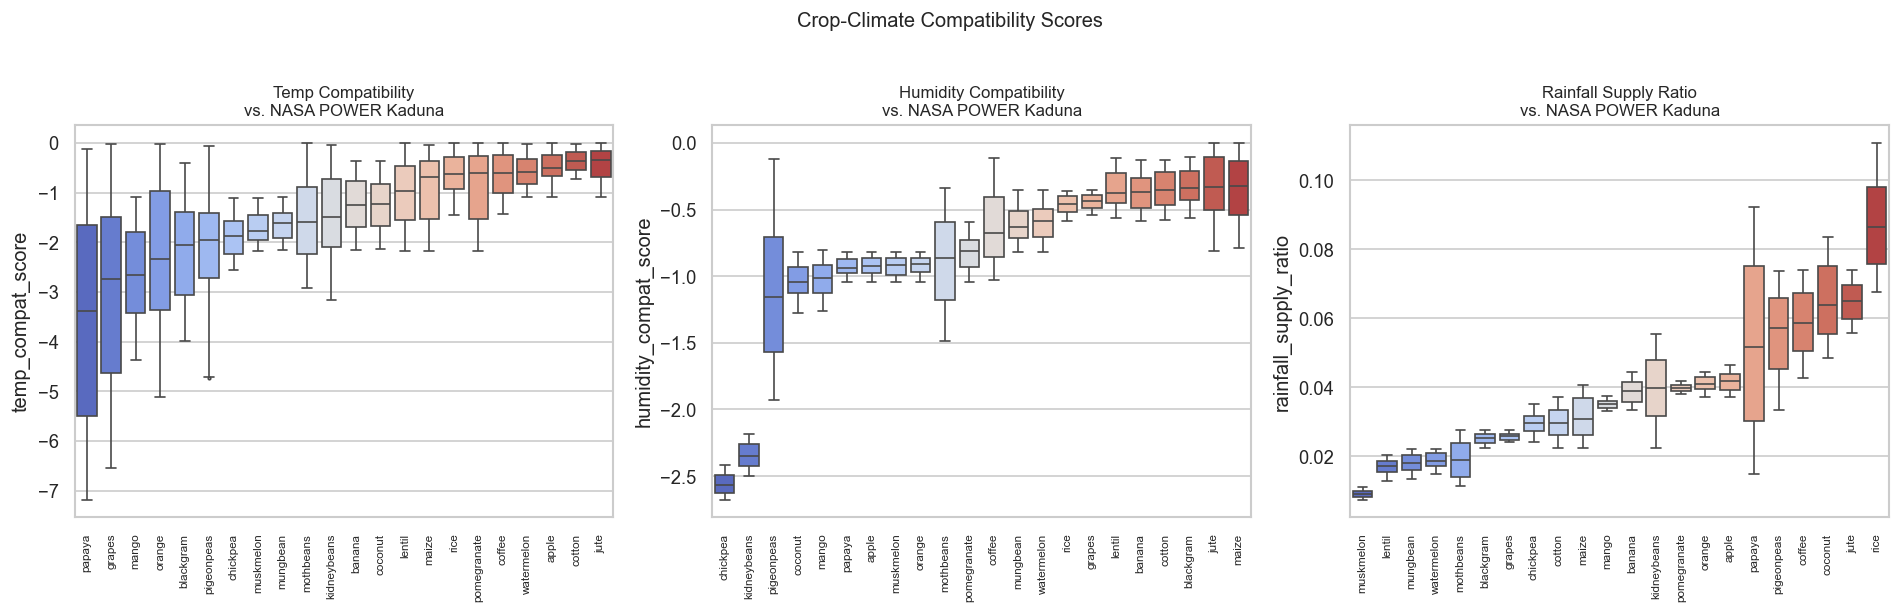

In [16]:
# Figure: Crop-climate compatibility box plots.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Temp Compatibility', 'Humidity Compatibility', 'Rainfall Supply Ratio']
for ax, col, title in zip(axes, compat_cols, titles):
    order = df.groupby('label')[col].median().sort_values().index
    sns.boxplot(
        data=df, x='label', y=col, order=order,
        ax=ax, palette='coolwarm', fliersize=1.5
    )
    ax.set_title(f'{title}\nvs. NASA POWER Kaduna', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=90, labelsize=7)

plt.suptitle('Crop-Climate Compatibility Scores', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('climate_compat.png', dpi=150)
plt.show()

## 4 · Preprocessing — Train/Test Split & Leak-Free Winsorization

In [17]:
# ── Define named feature groups (reused by ablation study) ────────────────────
BASELINE_FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

SOIL_RATIO_FEATURES = BASELINE_FEATURES + ['NP_ratio', 'NK_ratio', 'PK_ratio', 'NPK_sum']

CLIMATE_COMPAT_FEATURES = BASELINE_FEATURES + [
    'temp_compat_score', 'humidity_compat_score', 'rainfall_supply_ratio'
]

FULL_FEATURES = BASELINE_FEATURES + [
    'NP_ratio', 'NK_ratio', 'PK_ratio', 'NPK_sum',
    'temp_compat_score', 'humidity_compat_score', 'rainfall_supply_ratio',
    'crop_water_stress_idx', 'irrigation_sufficiency',
    'temp_humidity_interact', 'temp_rainfall_interact',
]

# Columns that benefit from outlier clipping (engineered ratios can be extreme).
# N and humidity were correctly excluded in v1 — they are well-bounded agronomically.
WINSOR_COLS = [
    'P', 'K', 'temperature', 'ph', 'rainfall',
    'humidity_compat_score', 'rainfall_supply_ratio',
    'crop_water_stress_idx', 'irrigation_sufficiency',
    'NP_ratio', 'NK_ratio', 'NPK_sum',
    'temp_humidity_interact', 'temp_rainfall_interact',
]

print(f'Baseline features      : {len(BASELINE_FEATURES)}')
print(f'+ Soil ratios          : {len(SOIL_RATIO_FEATURES)}')
print(f'+ Climate compat.      : {len(CLIMATE_COMPAT_FEATURES)}')
print(f'Full feature set       : {len(FULL_FEATURES)}')

Baseline features      : 7
+ Soil ratios          : 11
+ Climate compat.      : 10
Full feature set       : 18


In [18]:
# Encode labels.
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])
n_classes = len(label_encoder.classes_)
print(f'Classes: {n_classes}  |  Label shape: {y.shape}')

Classes: 22  |  Label shape: (2200,)


In [19]:
FEATURE_NAMES = FULL_FEATURES.copy()
X_full = df[FULL_FEATURES].values

# ── STEP 1: Split FIRST ────────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f'Train : {X_train_raw.shape}  |  Test : {X_test_raw.shape}')

Train : (1760, 18)  |  Test : (440, 18)


In [20]:
# ── STEP 2: Compute winsorization limits on TRAINING data only ─────────────────
# We clip each column to the 2nd–98th percentile of the training distribution,
# then apply those same clip bounds to the test set.
WINSOR_LIMIT = 0.05  # 5% per tail — conservative, justified choice

train_df_temp = pd.DataFrame(X_train_raw, columns=FULL_FEATURES)
test_df_temp  = pd.DataFrame(X_test_raw,  columns=FULL_FEATURES)

clip_bounds = {}  # store (lower, upper) for each column

for col in WINSOR_COLS:
    if col not in FULL_FEATURES:
        continue
    lo = train_df_temp[col].quantile(WINSOR_LIMIT)
    hi = train_df_temp[col].quantile(1 - WINSOR_LIMIT)
    clip_bounds[col] = (lo, hi)
    train_df_temp[col] = train_df_temp[col].clip(lo, hi)
    test_df_temp[col]  = test_df_temp[col].clip(lo, hi)   # apply SAME bounds to test

X_train_raw = train_df_temp.values
X_test_raw  = test_df_temp.values

print(f'Winsorization applied at {WINSOR_LIMIT*100:.0f}% per tail (train bounds → test).')
print(f'Columns clipped: {list(clip_bounds.keys())}')

Winsorization applied at 5% per tail (train bounds → test).
Columns clipped: ['P', 'K', 'temperature', 'ph', 'rainfall', 'humidity_compat_score', 'rainfall_supply_ratio', 'crop_water_stress_idx', 'irrigation_sufficiency', 'NP_ratio', 'NK_ratio', 'NPK_sum', 'temp_humidity_interact', 'temp_rainfall_interact']


In [21]:
# ── STEP 3: Scale (fit on train only, transform both) ─────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Final train matrix: {X_train_sc.shape}  |  Test matrix: {X_test_sc.shape}')

Final train matrix: (1760, 18)  |  Test matrix: (440, 18)


## 5 · Model Training

We evaluate each base learner with **two metrics**: accuracy and macro-averaged F1.
Macro-F1 treats all 22 classes equally and is more informative than accuracy alone
for multi-class problems.

In [22]:
def evaluate_pipeline(estimator, X, y, cv, label: str) -> dict:
    """
    Wrap estimator in a StandardScaler → estimator Pipeline,
    run stratified CV with both accuracy and macro-F1,
    and return a result dict.

    FIX: Now reports macro-F1 alongside accuracy.
    Also returns raw fold scores for downstream significance testing.
    """
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  estimator)
    ])
    cv_out = cross_validate(
        pipe, X, y, cv=cv,
        scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
        n_jobs=N_JOBS, return_train_score=False
    )
    result = {
        'Model'          : label,
        'CV Acc %'       : round(cv_out['test_accuracy'].mean() * 100, 2),
        'CV Acc Std %'   : round(cv_out['test_accuracy'].std()  * 100, 2),
        'CV F1-macro %'  : round(cv_out['test_f1_macro'].mean() * 100, 2),
        'CV F1 Std %'    : round(cv_out['test_f1_macro'].std()  * 100, 2),
        '_acc_folds'     : cv_out['test_accuracy'],   # raw folds for stat tests
        '_f1_folds'      : cv_out['test_f1_macro'],
    }
    print(
        f'  {label:8s}: Acc={result["CV Acc %"]:.2f}%±{result["CV Acc Std %"]:.2f}% '
        f'| F1={result["CV F1-macro %"]:.2f}%±{result["CV F1 Std %"]:.2f}%'
    )
    return result

print('5-fold stratified CV — base learners on full feature set:\n')

5-fold stratified CV — base learners on full feature set:



In [23]:
# ── Base learner definitions ───────────────────────────────────────────────────
# Hyperparameters reflect regularisation-aware settings chosen by domain knowledge.
# A coarse RandomizedSearchCV over these ranges is recommended for future work.

rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=SEED,
    n_jobs=N_JOBS
)

xgb_clf = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=N_JOBS,
    verbosity=0
)

lgb_clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=N_JOBS,
    verbose=-1
)

BASE_LEARNERS = [('RF', rf_clf), ('XGB', xgb_clf), ('LGBM', lgb_clf)]
print(f'{len(BASE_LEARNERS)} base learners defined.')

3 base learners defined.


In [24]:
cv_results = []
print('5-Fold CV results:\n')
for label, estimator in BASE_LEARNERS:
    cv_results.append(evaluate_pipeline(estimator, X_train_raw, y_train, skf, label))

# Separate raw fold scores for significance tests (not displayed in summary table).
fold_scores = {r['Model']: r['_acc_folds'] for r in cv_results}

cv_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in cv_results
])
cv_df

5-Fold CV results:

  RF      : Acc=99.09%±0.68% | F1=99.07%±0.72%
  XGB     : Acc=99.03%±0.43% | F1=99.03%±0.42%
  LGBM    : Acc=99.26%±0.23% | F1=99.26%±0.22%


,Model,CV Acc %,CV Acc Std %,CV F1-macro %,CV F1 Std %
0,RF,99.09,0.68,99.07,0.72
1,XGB,99.03,0.43,99.03,0.42
2,LGBM,99.26,0.23,99.26,0.22


In [25]:
# ── Fit base learners on full training set for held-out test evaluation ────────
print('Fitting base learners on training set...\n')
test_results = []

for label, model in BASE_LEARNERS:
    model.fit(X_train_sc, y_train)
    preds   = model.predict(X_test_sc)
    test_acc = accuracy_score(y_test, preds)
    test_f1  = f1_score(y_test, preds, average='macro')
    test_results.append({
        'Model'       : label,
        'Test Acc %'  : round(test_acc * 100, 2),
        'Test F1 %'   : round(test_f1  * 100, 2),
    })
    print(f'  {label:6s}: Test Acc={test_acc*100:.2f}%  F1-macro={test_f1*100:.2f}%')

Fitting base learners on training set...

  RF    : Test Acc=99.55%  F1-macro=99.55%
  XGB   : Test Acc=99.55%  F1-macro=99.54%
  LGBM  : Test Acc=99.55%  F1-macro=99.54%


## 6 · Stacking Ensemble

In [26]:
# Two-level stacking: RF + XGB + LGBM → LogisticRegression meta-learner.
# cv=skf ensures out-of-fold meta-features, preventing target leakage.
stacking_clf = StackingClassifier(
    estimators=[(label.lower(), clf) for label, clf in BASE_LEARNERS],
    final_estimator=LogisticRegression(
        max_iter=1000, C=1.0, random_state=SEED, n_jobs=N_JOBS
    ),
    cv=skf, stack_method='predict_proba', passthrough=False, n_jobs=N_JOBS
)

print('Fitting stacking ensemble...')
stacking_clf.fit(X_train_sc, y_train)

stack_pred = stacking_clf.predict(X_test_sc)
stack_acc  = accuracy_score(y_test, stack_pred)
stack_f1   = f1_score(y_test, stack_pred, average='macro')

test_results.append({
    'Model'     : 'Stacking',
    'Test Acc %': round(stack_acc * 100, 2),
    'Test F1 %' : round(stack_f1  * 100, 2),
})
print(f'\nStacking — Test Acc: {stack_acc*100:.2f}%  |  F1-macro: {stack_f1*100:.2f}%')

Fitting stacking ensemble...

Stacking — Test Acc: 99.55%  |  F1-macro: 99.54%


In [27]:
# ── Full model comparison table ────────────────────────────────────────────────
test_df  = pd.DataFrame(test_results)
final_df = pd.merge(cv_df, test_df, on='Model', how='outer')
print('Full Model Comparison (Accuracy + Macro-F1):')
print(final_df[[
    'Model', 'CV Acc %', 'CV Acc Std %', 'CV F1-macro %', 'CV F1 Std %',
    'Test Acc %', 'Test F1 %'
]].to_string(index=False))

Full Model Comparison (Accuracy + Macro-F1):
   Model  CV Acc %  CV Acc Std %  CV F1-macro %  CV F1 Std %  Test Acc %  Test F1 %
      RF     99.09          0.68          99.07         0.72       99.55      99.55
     XGB     99.03          0.43          99.03         0.42       99.55      99.54
    LGBM     99.26          0.23          99.26         0.22       99.55      99.54
Stacking       NaN           NaN            NaN          NaN       99.55      99.54


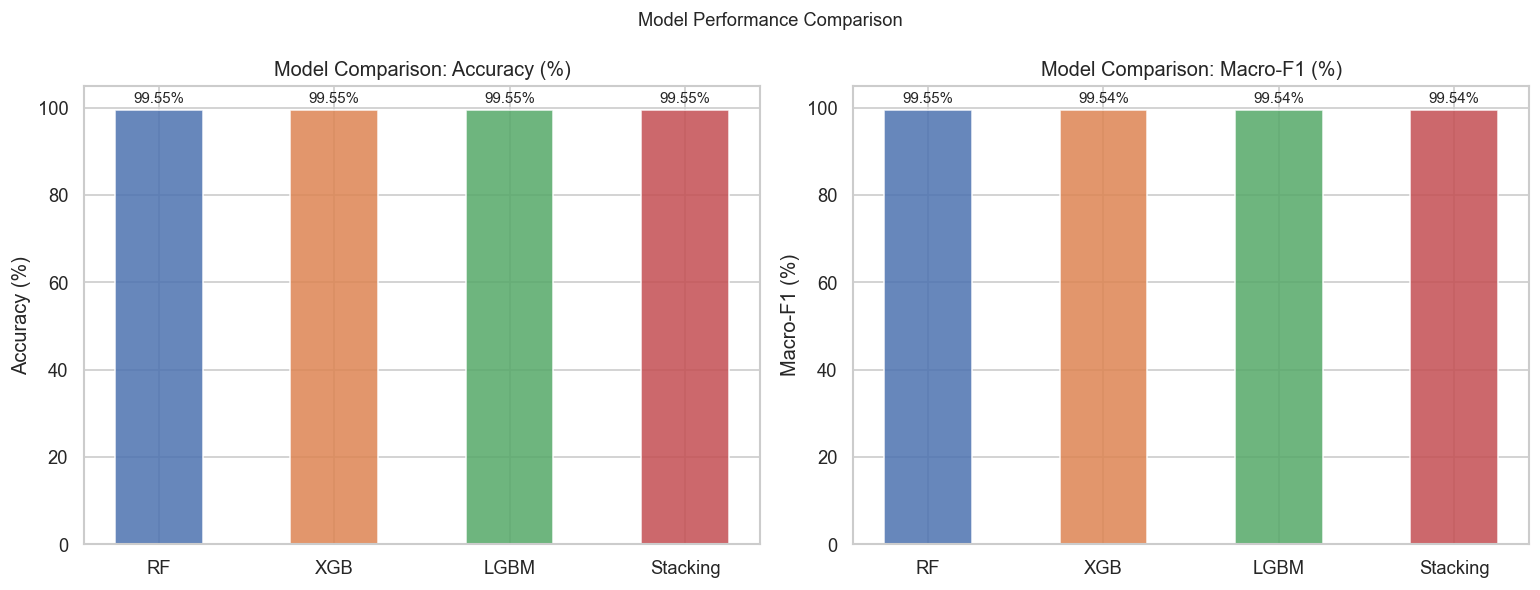

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

for ax, metric, ylabel in zip(axes, ['Test Acc %', 'Test F1 %'],
    ['Accuracy (%)', 'Macro-F1 (%)']):
    bars = ax.bar(test_df['Model'], test_df[metric],
        color = colors[:len(test_df)], width = 0.5, alpha = 0.85)
    ax.set_ylim(0, 105)
    ax.set_ylabel(ylabel)
    ax.set_title(f'Model Comparison: {ylabel}')
    for bar in bars:
        ax.annotate( f'{bar.get_height():.2f}%',
            xy = (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext = (0, 4), textcoords = 'offset points', ha = 'center', fontsize = 9)

fig.suptitle('Model Performance Comparison', fontsize = 11)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

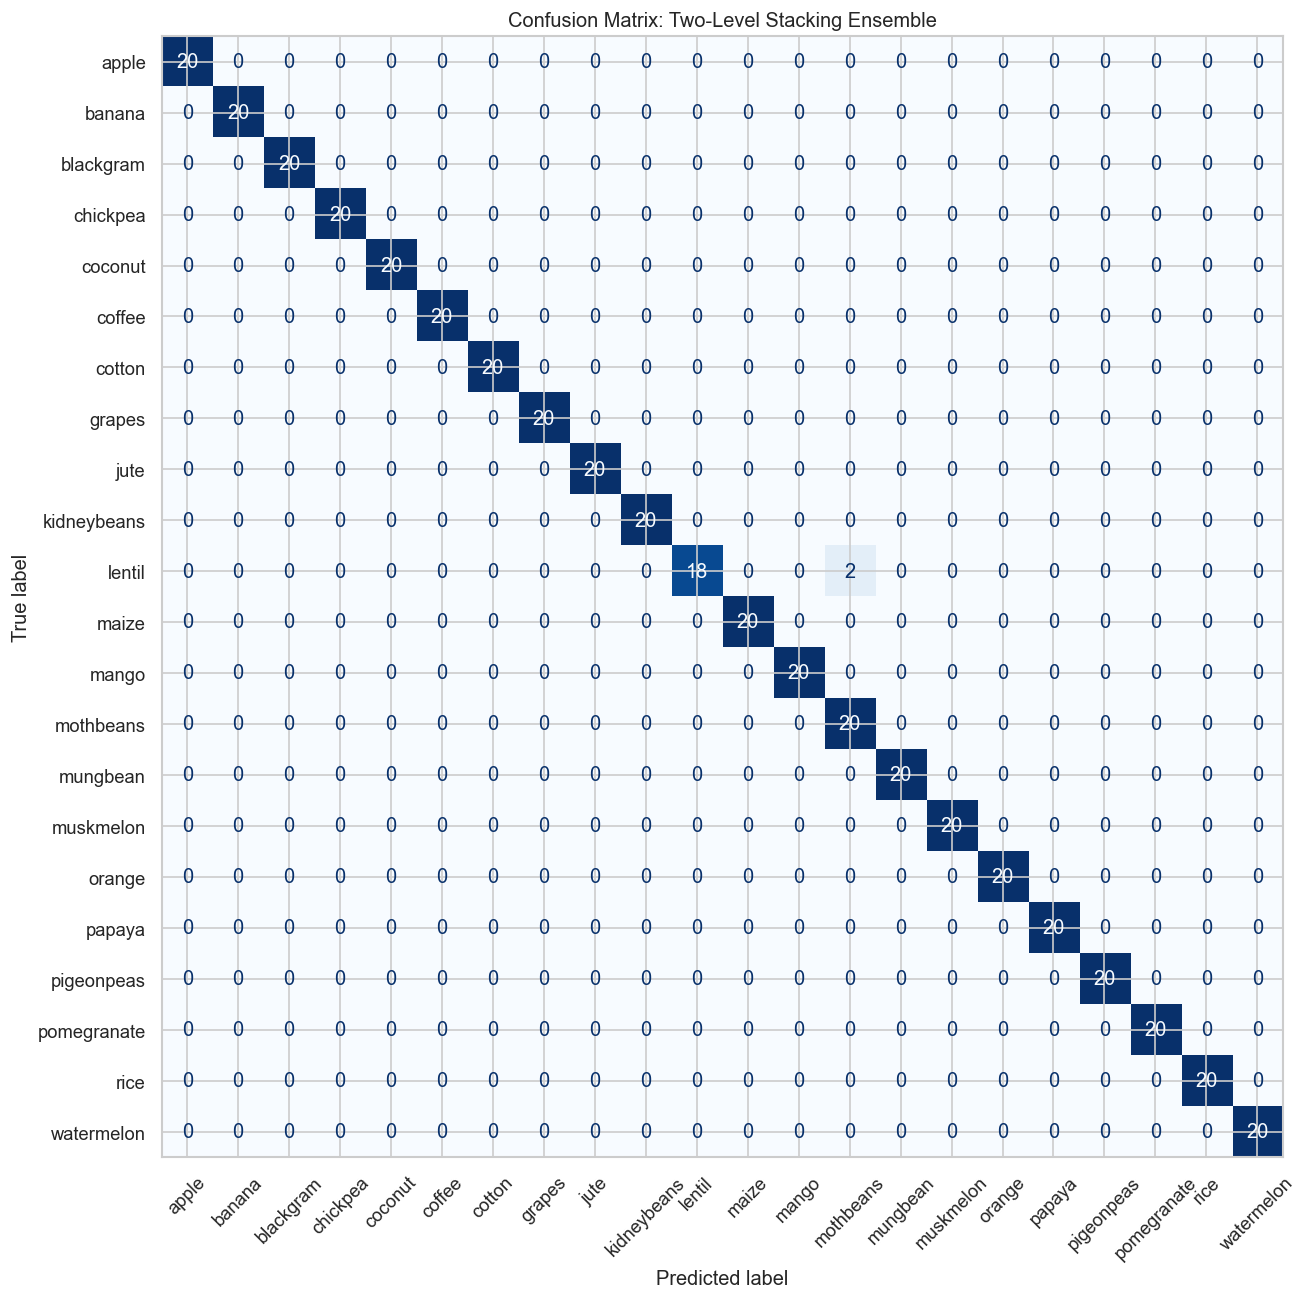

In [29]:
# ── Confusion matrix — stacking ensemble ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, stack_pred),
    display_labels=label_encoder.classes_
).plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('Confusion Matrix: Two-Level Stacking Ensemble')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [30]:
# ── Classification reports ─────────────────────────────────────────────────────
for label, model in BASE_LEARNERS + [('Stacking', stacking_clf)]:
    preds = model.predict(X_test_sc)
    print(f'\nClassification Report — {label}')
    print(classification_report(y_test, preds, target_names=label_encoder.classes_))


Classification Report — RF
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20

## 7 · Ablation Study

In [31]:
ABLATION_GROUPS = [
    ('1. Baseline',               BASELINE_FEATURES),
    ('2. Baseline + Soil Ratios', SOIL_RATIO_FEATURES),
    ('3. Baseline + Climate',     CLIMATE_COMPAT_FEATURES),
    ('4. Full Feature Set',       FULL_FEATURES),
]


def run_ablation_single(estimator, model_label: str, groups: list,
    df_full: pd.DataFrame, y: np.ndarray, cv: StratifiedKFold) -> pd.DataFrame:
    """
    Run ablation study for ONE estimator across all feature groups.
    Returns a DataFrame with CV accuracy, std, and raw fold scores.
    """
    records = []
    for group_label, features in groups:
        X_group = df_full[features].values
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model',  estimator)
        ])
        scores = cross_val_score(pipe, X_group, y, cv = cv, scoring = 'accuracy', n_jobs = N_JOBS)
        records.append({
            'Model'         : model_label,
            'Feature Group' : group_label,
            'N Features'    : len(features),
            'CV Acc %'      : round(scores.mean() * 100, 2),
            'CV Std %'      : round(scores.std()  * 100, 2),
            '_folds'        : scores,
        })
        print(
            f'  [{model_label}] {group_label:<35s} n={len(features):2d} '
            f'| {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%'
        )
    return pd.DataFrame(records)


In [32]:
# We reuse the same hyperparameters as the main learners above.
ablation_estimators = [
    ('XGB',  XGBClassifier(
        n_estimators=400, learning_rate=0.03, max_depth=5,
        min_child_weight=3, gamma=0.1, subsample=0.8,
        colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.5,
        eval_metric='mlogloss', random_state=SEED, n_jobs=N_JOBS, verbosity=0
    )),
    ('RF',   RandomForestClassifier(
        n_estimators=500, max_depth=12, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt',
        random_state=SEED, n_jobs=N_JOBS
    )),
    ('LGBM', LGBMClassifier(
        n_estimators=500, learning_rate=0.03, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, n_jobs=N_JOBS, verbose=-1
    )),
]

df_for_ablation = pd.DataFrame(X_train_raw, columns=FULL_FEATURES)

all_ablation_rows = []
for model_label, est in ablation_estimators:
    print(f'\nAblation — {model_label}:')
    sub_df = run_ablation_single(est, model_label, ABLATION_GROUPS, df_for_ablation, y_train, skf)
    all_ablation_rows.append(sub_df)

ablation_all = pd.concat(all_ablation_rows, ignore_index=True)


Ablation — XGB:
  [XGB] 1. Baseline                         n= 7 | 99.32% ± 0.29%
  [XGB] 2. Baseline + Soil Ratios           n=11 | 98.92% ± 0.38%
  [XGB] 3. Baseline + Climate               n=10 | 99.32% ± 0.43%
  [XGB] 4. Full Feature Set                 n=18 | 99.03% ± 0.43%

Ablation — RF:
  [RF] 1. Baseline                         n= 7 | 99.38% ± 0.55%
  [RF] 2. Baseline + Soil Ratios           n=11 | 99.43% ± 0.48%
  [RF] 3. Baseline + Climate               n=10 | 99.20% ± 1.04%
  [RF] 4. Full Feature Set                 n=18 | 99.09% ± 0.68%

Ablation — LGBM:
  [LGBM] 1. Baseline                         n= 7 | 99.32% ± 0.14%
  [LGBM] 2. Baseline + Soil Ratios           n=11 | 99.26% ± 0.23%
  [LGBM] 3. Baseline + Climate               n=10 | 99.43% ± 0.18%
  [LGBM] 4. Full Feature Set                 n=18 | 99.26% ± 0.23%


In [33]:
# ── Ablation summary table ─────────────────────────────────────────────────────
abl_display = ablation_all[['Model', 'Feature Group', 'N Features', 'CV Acc %', 'CV Std %']].copy()

# Add gain over baseline per model
gains = []
for model_label, _ in ablation_estimators:
    sub = abl_display[abl_display['Model'] == model_label].copy()
    baseline_val = sub.loc[sub['Feature Group'].str.startswith('1'), 'CV Acc %'].values[0]
    sub['Gain %'] = (sub['CV Acc %'] - baseline_val).round(2)
    gains.append(sub)

abl_display = pd.concat(gains).reset_index(drop=True)
print(abl_display.to_string(index=False))

Model             Feature Group  N Features  CV Acc %  CV Std %  Gain %
  XGB               1. Baseline           7     99.32      0.29    0.00
  XGB 2. Baseline + Soil Ratios          11     98.92      0.38   -0.40
  XGB     3. Baseline + Climate          10     99.32      0.43    0.00
  XGB       4. Full Feature Set          18     99.03      0.43   -0.29
   RF               1. Baseline           7     99.38      0.55    0.00
   RF 2. Baseline + Soil Ratios          11     99.43      0.48    0.05
   RF     3. Baseline + Climate          10     99.20      1.04   -0.18
   RF       4. Full Feature Set          18     99.09      0.68   -0.29
 LGBM               1. Baseline           7     99.32      0.14    0.00
 LGBM 2. Baseline + Soil Ratios          11     99.26      0.23   -0.06
 LGBM     3. Baseline + Climate          10     99.43      0.18    0.11
 LGBM       4. Full Feature Set          18     99.26      0.23   -0.06


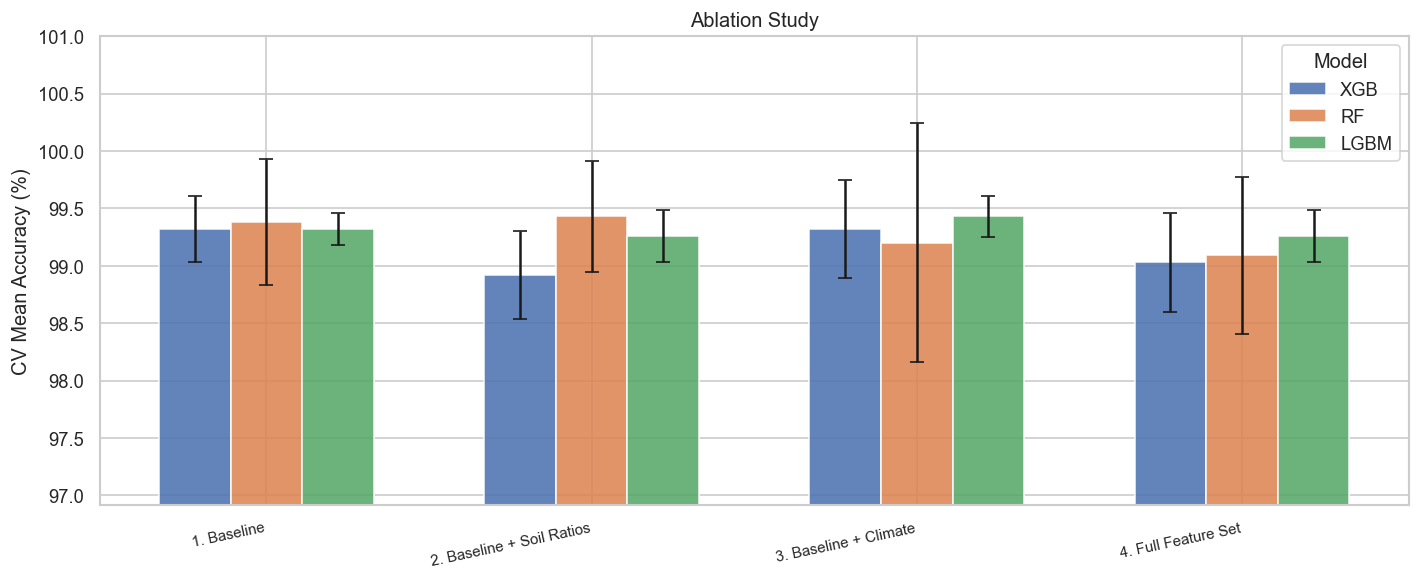

In [34]:
# ── Ablation chart — grouped bar by model ─────────────────────────────────────
group_labels  = [g[0] for g in ABLATION_GROUPS]
model_labels  = [m[0] for m in ablation_estimators]
n_groups      = len(group_labels)
n_models      = len(model_labels)
bar_width     = 0.22
x             = np.arange(n_groups)
palette       = ['#4c72b0', '#dd8452', '#55a868']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (m_label, color) in enumerate(zip(model_labels, palette)):
    sub = abl_display[abl_display['Model'] == m_label]
    offset = (i - n_models / 2 + 0.5) * bar_width
    bars = ax.bar(
        x + offset, sub['CV Acc %'], yerr=sub['CV Std %'],
        width=bar_width, alpha=0.87, color=color,
        capsize=4, label=m_label
    )

ax.set_xticks(x)
ax.set_xticklabels(group_labels, rotation=12, ha='right', fontsize=9)
ax.set_ylim(abl_display['CV Acc %'].min() - 2, 101)
ax.set_ylabel('CV Mean Accuracy (%)')
ax.set_title('Ablation Study')
ax.legend(title='Model')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

## 8 · SHAP Explainability


In [35]:
# SHAP sample from the UNSCALED test set (tree models are scale-invariant).
# Using unscaled data means beeswarm colour gradients reflect real feature values.
shap_sample_size = min(400, len(X_test_raw))
shap_idx         = rng.choice(len(X_test_raw), size=shap_sample_size, replace=False)
X_shap_raw       = X_test_raw[shap_idx]   # unscaled — for SHAP
X_shap_sc        = X_test_sc[shap_idx]    # scaled — kept for reference if needed

print(f'SHAP sample size: {shap_sample_size} rows (unscaled)')

SHAP sample size: 400 rows (unscaled)


In [36]:
shap_models = [('RF', rf_clf), ('XGB', xgb_clf), ('LGBM', lgb_clf)]
shap_values = {}

for name, model in shap_models:
    explainer = shap.TreeExplainer(model)
    raw_vals  = np.array(explainer.shap_values(X_shap_raw))

    # Collapse multi-class SHAP to mean |SHAP| across classes and samples.
    if raw_vals.ndim == 3 and raw_vals.shape[0] == n_classes:
        # Shape: (n_classes, n_samples, n_features)
        per_feature = np.abs(raw_vals).mean(axis=0).mean(axis=0)
    elif raw_vals.ndim == 3 and raw_vals.shape[2] == n_classes:
        # Shape: (n_samples, n_features, n_classes)
        per_feature = np.abs(raw_vals).mean(axis=2).mean(axis=0)
    else:
        per_feature = np.abs(raw_vals).mean(axis=0)

    shap_values[name] = per_feature
    print(f'{name}: SHAP computed — {len(per_feature)} features')

RF: SHAP computed — 18 features
XGB: SHAP computed — 18 features
LGBM: SHAP computed — 18 features


In [37]:
# ── Cross-model SHAP consensus table ──────────────────────────────────────────
shap_consensus_df = pd.DataFrame({
    'Feature' : FEATURE_NAMES,
    'RF_SHAP' : shap_values['RF'],
    'XGB_SHAP': shap_values['XGB'],
    'LGBM_SHAP': shap_values['LGBM'],
})
shap_consensus_df['Consensus'] = shap_consensus_df[['RF_SHAP', 'XGB_SHAP', 'LGBM_SHAP']].mean(axis=1)
shap_consensus_df['Std']       = shap_consensus_df[['RF_SHAP', 'XGB_SHAP', 'LGBM_SHAP']].std(axis=1)

# FIX: Percentage computed over ALL features, not just top-10.
total_importance = shap_consensus_df['Consensus'].sum()
shap_consensus_df['% of Total'] = (
    shap_consensus_df['Consensus'] / total_importance * 100
).round(1)

shap_consensus_df = shap_consensus_df.sort_values('Consensus', ascending=False).reset_index(drop=True)
shap_consensus_df.round(4)

,Feature,RF_SHAP,XGB_SHAP,LGBM_SHAP,Consensus,Std,% of Total
0,humidity,0.0163,0.5674,0.4987,0.3608,0.3003,14.2
1,P,0.0179,0.3236,0.6128,0.3181,0.2975,12.6
2,NPK_sum,0.0243,0.4734,0.2238,0.2405,0.2251,9.5
3,rainfall,0.0073,0.4024,0.2972,0.2356,0.2046,9.3
4,PK_ratio,0.0040,0.2770,0.2814,0.1875,0.1589,7.4
5,K,0.0231,0.2350,0.2625,0.1735,0.1310,6.9
6,temp_humidity_interact,0.0042,0.2453,0.2119,0.1538,0.1306,6.1
7,NK_ratio,0.0040,0.2302,0.2137,0.1493,0.1261,5.9
8,humidity_compat_score,0.0072,0.2789,0.1566,0.1476,0.1361,5.8
9,N,0.0135,0.1137,0.2065,0.1113,0.0965,4.4


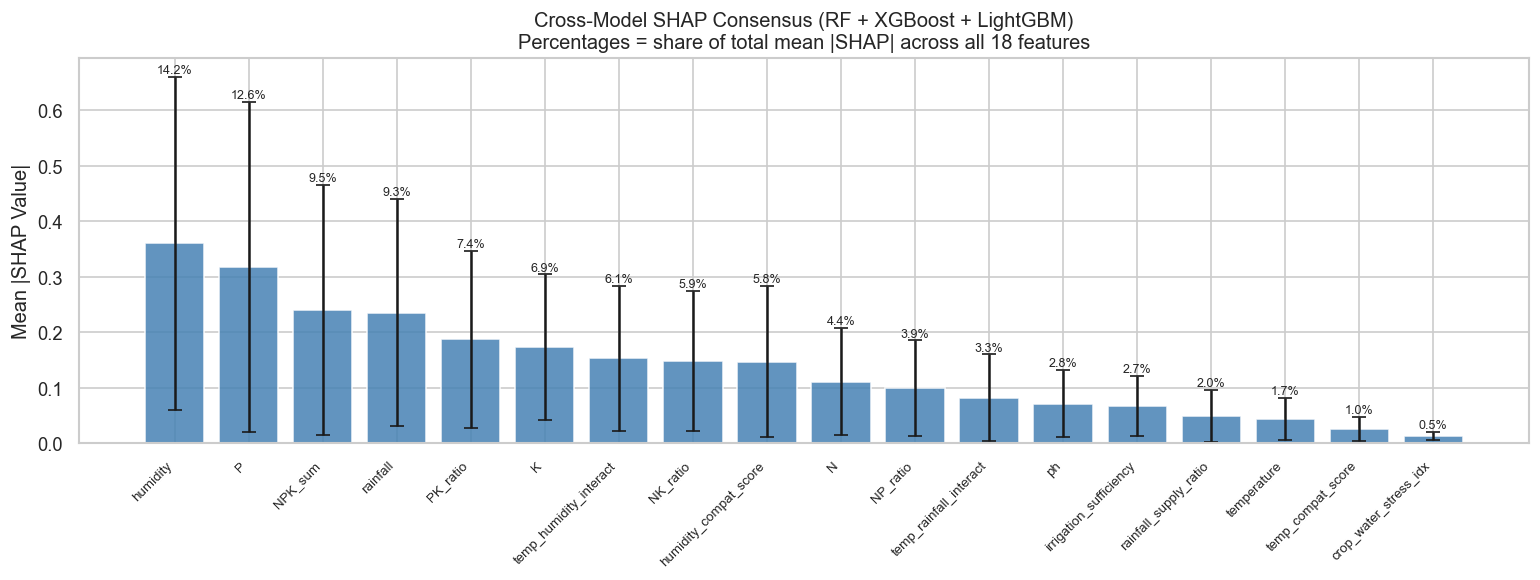

In [38]:
# ── Figure: Cross-model SHAP consensus (all features) ─────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
x_pos = np.arange(len(shap_consensus_df))
ax.bar(
    x_pos, shap_consensus_df['Consensus'],
    yerr=shap_consensus_df['Std'], capsize=4,
    color='steelblue', alpha=0.85
)
for i, row in shap_consensus_df.iterrows():
    ax.text(
        i, row['Consensus'] + shap_consensus_df['Std'].iloc[i] + 0.001,
        f"{row['% of Total']:.1f}%",
        ha='center', va='bottom', fontsize=7.5
    )
ax.set_xticks(x_pos)
ax.set_xticklabels(shap_consensus_df['Feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean |SHAP Value|')
ax.set_title(
    'Cross-Model SHAP Consensus (RF + XGBoost + LightGBM)\n'
    'Percentages = share of total mean |SHAP| across all 18 features'
)
plt.tight_layout()
plt.savefig('shap_consensus.png', dpi=150)
plt.show()

Most confused class: lentil (class index 10)


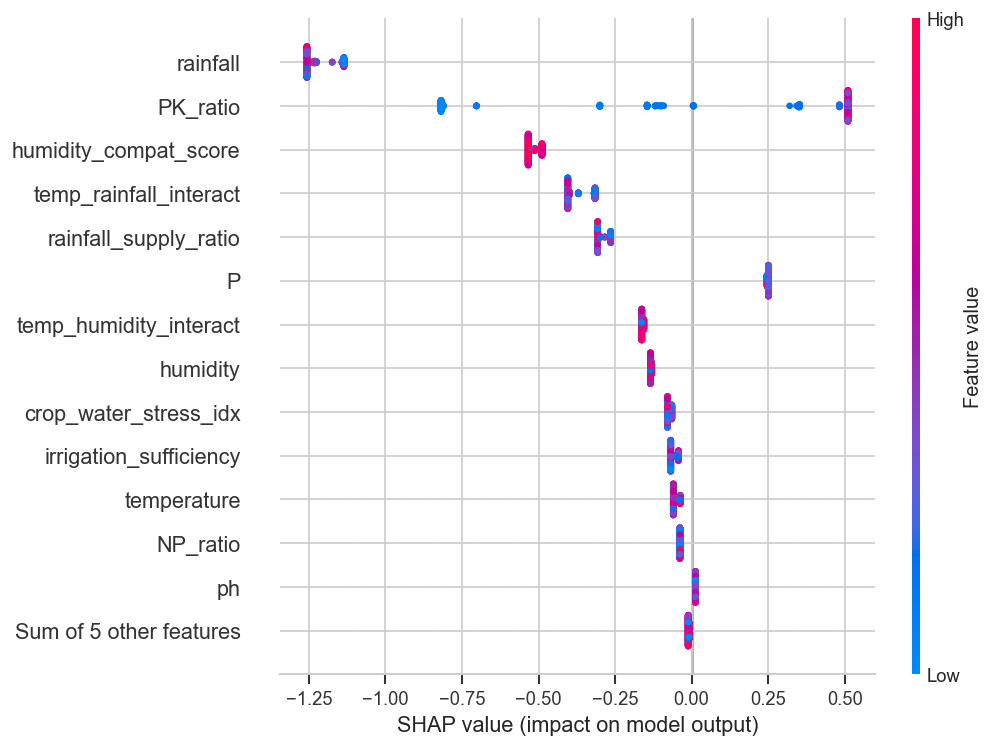

In [39]:
cm = confusion_matrix(y_test, stack_pred)
np.fill_diagonal(cm, 0)          # zero the diagonal — we want off-diagonal errors
most_confused_class = int(cm.sum(axis=1).argmax())
most_confused_name  = label_encoder.classes_[most_confused_class]
print(f'Most confused class: {most_confused_name} (class index {most_confused_class})')

xgb_explainer = shap.TreeExplainer(xgb_clf)
xgb_shap_exp  = xgb_explainer(X_shap_raw)   # unscaled — real feature units in colour axis

if xgb_shap_exp.values.ndim == 3:
    single_class_exp = shap.Explanation(
        values       = xgb_shap_exp.values[:, :, most_confused_class],
        base_values  = xgb_shap_exp.base_values[:, most_confused_class],
        data         = X_shap_raw,
        feature_names = FULL_FEATURES
    )
    shap.plots.beeswarm(single_class_exp, max_display=14, show=True)
else:
    shap.plots.beeswarm(xgb_shap_exp, max_display=14, show=True)

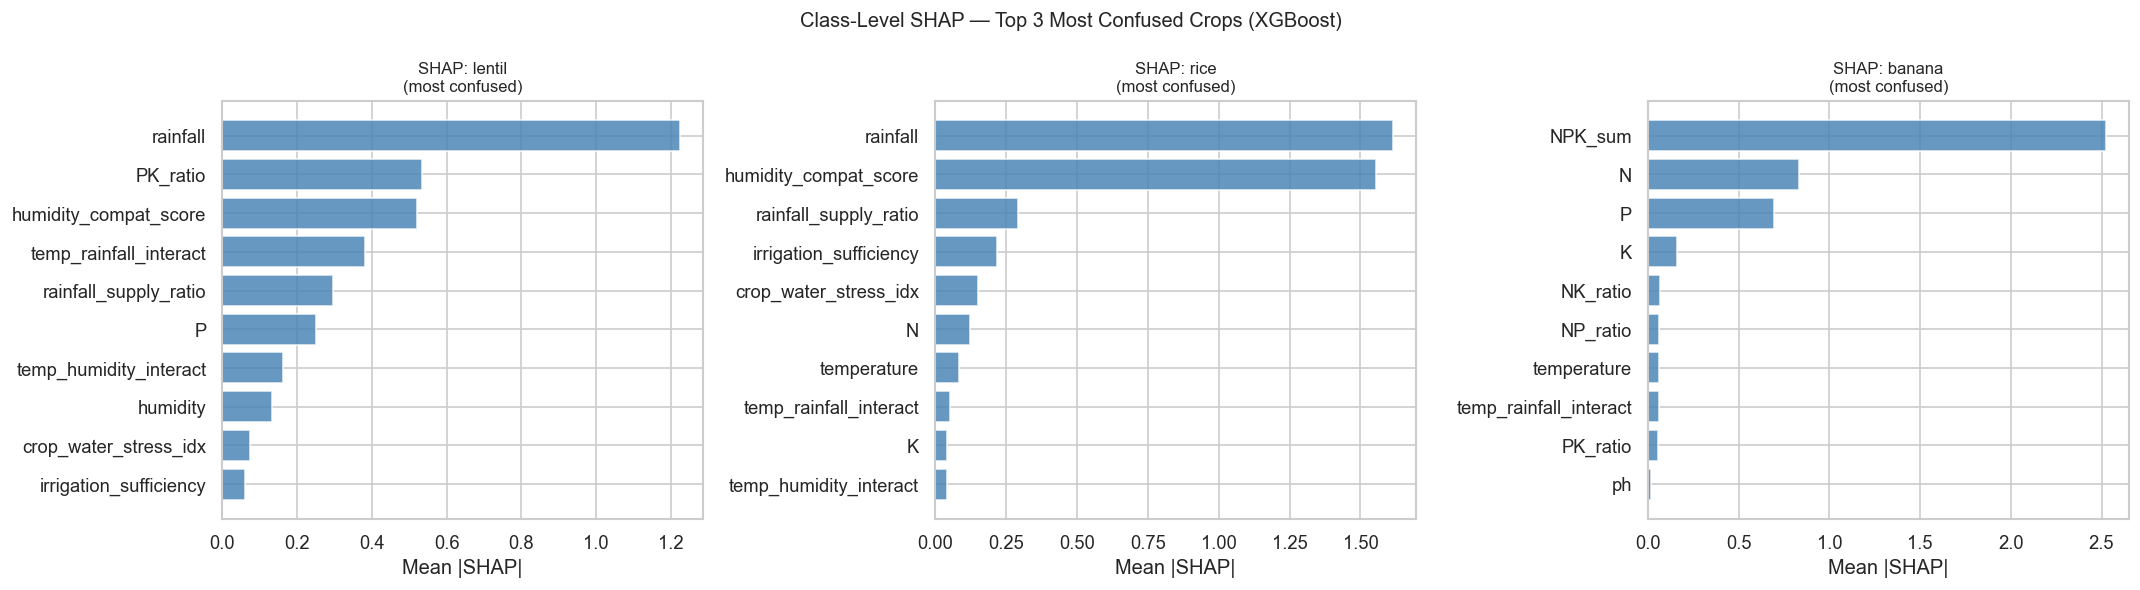

In [40]:
cm_full = confusion_matrix(y_test, stack_pred)
np.fill_diagonal(cm_full, 0)
top3_confused = np.argsort(cm_full.sum(axis=1))[-3:][::-1]

xgb_raw_shap = np.array(xgb_explainer.shap_values(X_shap_raw))

# Normalise to (n_samples, n_features, n_classes) if needed
if xgb_raw_shap.ndim == 3 and xgb_raw_shap.shape[0] == n_classes:
    xgb_raw_shap = xgb_raw_shap.transpose(1, 2, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cls_idx in zip(axes, top3_confused):
    cls_name = label_encoder.classes_[cls_idx]
    if xgb_raw_shap.ndim == 3:
        mean_abs_shap = np.abs(xgb_raw_shap[:, :, cls_idx]).mean(axis=0)
    else:
        mean_abs_shap = np.abs(xgb_raw_shap).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[-10:][::-1]
    ax.barh(
        [FULL_FEATURES[i] for i in top_idx[::-1]],
        mean_abs_shap[top_idx[::-1]],
        color='steelblue', alpha=0.82
    )
    ax.set_title(f'SHAP: {cls_name}\n(most confused)', fontsize=10)
    ax.set_xlabel('Mean |SHAP|')

plt.suptitle('Class-Level SHAP — Top 3 Most Confused Crops (XGBoost)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_class_level.png', dpi=150)
plt.show()